# Example for implementing event vs. data level PPCs using an analytic toy model

In [39]:
import numpy as np 
from scipy.integrate import cumulative_trapezoid
import tqdm 

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_palette('colorblind')

import sys
sys.path.append('../utils')
import plot_utils 

## Prologue: The underlying math

For this analytic toy model, we consider a single parameter $x$. Both the single event likelihood for $x$ and the population distirbution characterizing $x$ are Gaussian. The single-event likelihood is has a width $\sigma_\mathrm{meas}$ ("measurement uncertainty") and is centered at some $x_{\mathrm{max}\mathcal{L}}$ drawn randomly from $\mathcal{N}(x_{\rm true}, \sigma_{\rm meas})$. The population distribution is centered at $\mu$ and has width $\sigma$. 

Our hierarchical likelihood on $\mu, \sigma$ is therefore,  
$$ p(\mu, \sigma|\{d_i\})  = \prod_{i}^N  p(\mu, \sigma|d_i) $$
$$ p(\mu, \sigma|\{d_i\})  = \prod_{i}^N \int  \mathcal{L}(d_i|x) \, \pi_{\rm pop}(x | \mu, \sigma) \, dx~.$$

If we assume uniform priors on $\mu, \sigma$ and no selection effects on $x$, then 
$$ p(\mu, \sigma|\{d_i\})  = \prod_{i}^N \int  \mathcal{N}(x|x^{\mathrm{max}\mathcal{L},i}, \sigma_{\rm meas}) \, \mathcal{N}(x | \mu, \sigma) \, dx~.$$

Doing the Gaussian product integral yields
$$ p(\mu, \sigma|\{d_i\})  = \prod_{i}^N \mathcal{N}(x^{\mathrm{max}\mathcal{L},i}|\mu, \sqrt{\sigma^2 + \sigma_{\rm meas}^2})~.$$

Writing this out fully:
$$ p(\mu, \sigma|\{d_i\}) = \prod_{i}^N \, [2\pi \, (\sigma^2 + \sigma_{\rm meas}^2)]^{-1/2} \, \mathrm{Exp}\Bigg[ -\frac{1}{2} \frac{(x^{\mathrm{max}\mathcal{L},i} -\mu)^2}{\sigma^2 + \sigma_{\rm meas}^2}\Bigg]~.$$

We can turn the product into a sum in the exponent:
$$\boxed{p(\mu, \sigma|\{d_i\}) =  [2\pi \, (\sigma^2 + \sigma_{\rm meas}^2)]^{-N/2} \, \mathrm{Exp}\Bigg[ -\frac{1}{2 (\sigma^2 + \sigma_{\rm meas}^2)} \sum_{i}^N (x^{\mathrm{max}\mathcal{L},i} -\mu)^2\Bigg]}~.$$

The above boxed equation is analytically solvable for a given set of $\{x^{\mathrm{max}\mathcal{L},i}\}$.

## Step 1: Simulate a catalog with some hyper-parameters

In [2]:
# true hyper-parameters 
mu_pop_true = 1
sigma_pop_true = 0.4

# catalog size 
nevents = 300

# measurement uncertainty
sigma_meas = 0.5

# set up a random seed for reproducability 
rng = rng.default_rng(seed=13)

# draw true values
x_true = rng.normal(loc=mu_pop_true, scale=sigma_pop_true, size=nevents) 

# draw corresponding maxL values
x_maxL = rng.normal(loc=x_true, scale=sigma_meas)

Let's plot the population and our random draws from it.

In [3]:
def gaussian_pdf(x, mean, std_dev):
    """
    Calculates the Gaussian Probability Density Function (PDF) for a given x.

    Args:
        x (float or array-like): The value(s) at which to evaluate the PDF.
        mean (float): The mean of the Gaussian distribution.
        std_dev (float): The standard deviation of the Gaussian distribution.

    Returns:
        float or array-like: The PDF value(s) at x.
    """
    coefficient = 1 / (std_dev * np.sqrt(2 * np.pi))
    exponent = -0.5 * ((x - mean) / std_dev)**2
    pdf_value = coefficient * np.exp(exponent)
    return pdf_value

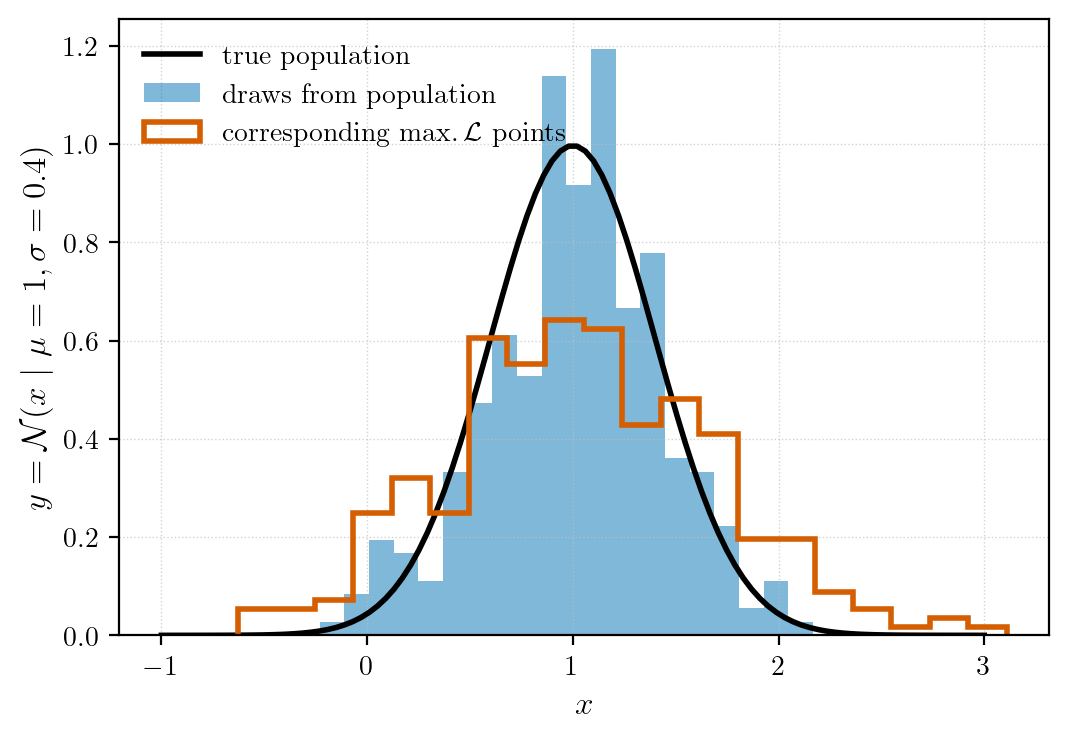

In [4]:
# Plot
x_grid = np.linspace(-1,3,100)
y_grid = gaussian_pdf(x_grid, mu_pop_true, sigma_pop_true)

plt.figure(figsize=(6,4))
plt.plot(x_grid, y_grid, color='k', lw=2, label='true population')
plt.hist(x_true, density=True, color='C0', alpha=0.5, bins=20, label='draws from population')
plt.hist(x_maxL, density=True, color='C3', histtype='step', lw=2, bins=20, label=r'corresponding $\mathrm{max.}\,\mathcal{L}$ points')

plt.legend(loc='upper left', frameon=False)
plt.xlabel(r'$x$')
plt.ylabel(r'$y = \mathcal{N}(x ~|~ \mu = 1, \sigma = 0.4)$')
plt.grid()
plt.show()

## Step 2: Analytically perform hierarchical inference

In [8]:
def hierarchical_log_likelihood(x_maxLs, sigma_meas, mu, sigma): 
    """
    Calculates hiearchical logL assuming both the population model and 
    individual event likelihoods are Gaussian.

    Args:
        x_maxLs (float or array-like): The maximum likelihood value(s) for
          the catalog.
        sigma_meas (float) : The individual-event measurement uncertainty
        mu (float or array-like): The mean of the Population Gaussian distribution.
        sigma (float or array-like): The standard deviation of the Population Gaussian 
          distribution.

    Returns:
        float or array-like: log liklihood value for (mu, sigma) hyper
          parameter. (NOT NORMALIZED!)
    """
    x_maxLs = np.asarray(x_maxLs)
    N = x_maxLs.size
    sig_sum_sq = sigma_meas**2 + sigma**2
    coefficient = np.power(2 *np.pi*sig_sum_sq, -N/2)
    exponent = -0.5 / sig_sum_sq * np.sum((x_maxLs[:, None, None] - mu)**2,axis=0)
    L = coefficient * np.exp(exponent)
    return np.log(L)

We will evaluate the hierarchical log likelihood over a grid of $\mu$ and $\sigma$ using the above function

In [14]:
# grid over mu, sigma
mu_grid = np.linspace(0.85,1.2,101)
sigma_grid = np.linspace(0.25,0.6,102)
MU, SIG = np.meshgrid(mu_grid, sigma_grid, indexing='ij')

# calculate hierarchical likelihood on the grid
hL = hierarchical_log_likelihood(x_maxL, sigma_meas, MU, SIG)

# take exponent
p = np.exp(hL)

# normalize
norm = np.trapz(np.trapz(p, x=sigma_grid), x=mu_grid)
hL = p / norm 

Now, plot the $\mu, \sigma$ posterior. Did it find our injected value?

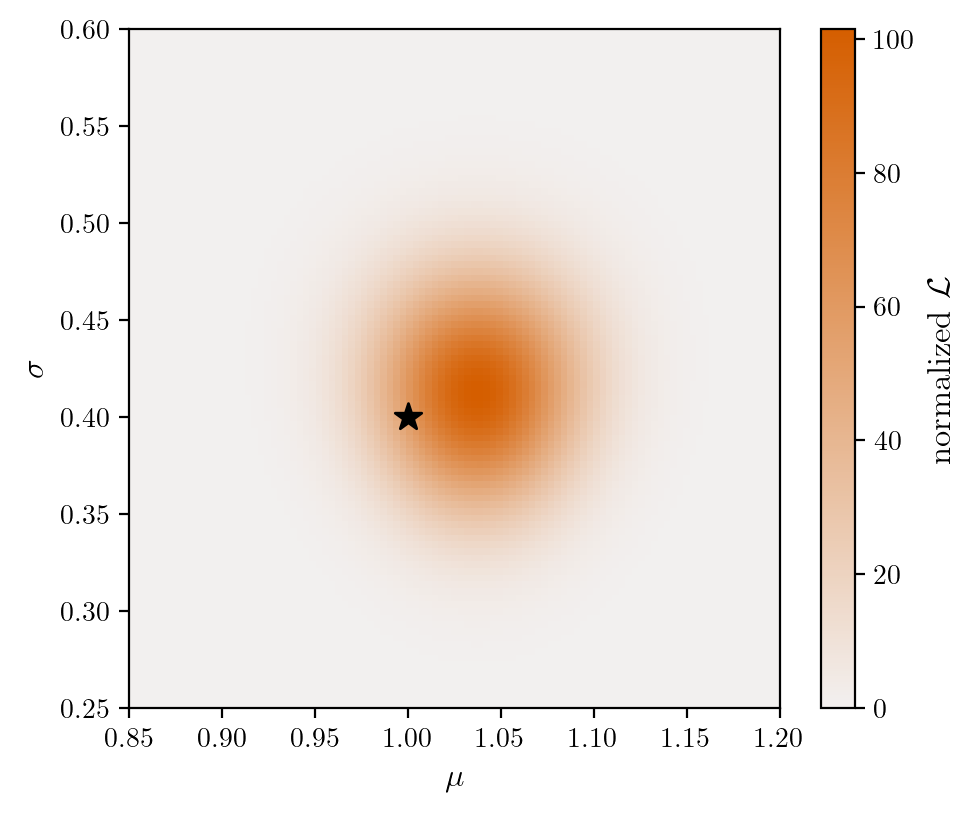

In [15]:
fig, ax = plt.subplots(figsize=(6/1.2,5/1.2))

im = ax.imshow(
    hL.T,
    origin='lower',
    aspect='auto',
    extent=[
        mu_grid[0], mu_grid[-1],
        sigma_grid[0], sigma_grid[-1]
    ],
    cmap = sns.light_palette('C3', as_cmap=True)
)

ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$\sigma$')

ax.scatter([mu_pop_true], [sigma_pop_true], color='k', marker='*', s=100, label='truth')

fig.colorbar(im, ax=ax, label=r'normalized $\mathcal{L}$')

plt.tight_layout()

We can also plot marginalized $\mu$ and $\sigma$ PDFs and CDFs:

In [24]:
# PDFs
p_mu = np.trapz(hL, x=sigma_grid, axis=-1)
p_mu /= np.trapz(p_mu, x=mu_grid) # normalize

p_sigma = np.trapz(hL, x=mu_grid, axis=0)
p_sigma /= np.trapz(p_sigma, x=sigma_grid) # normalize

# CDFs
cdf_mu = cumulative_trapezoid(p_mu, x=mu_grid)
cdf_sigma = cumulative_trapezoid(p_sigma, x=sigma_grid)

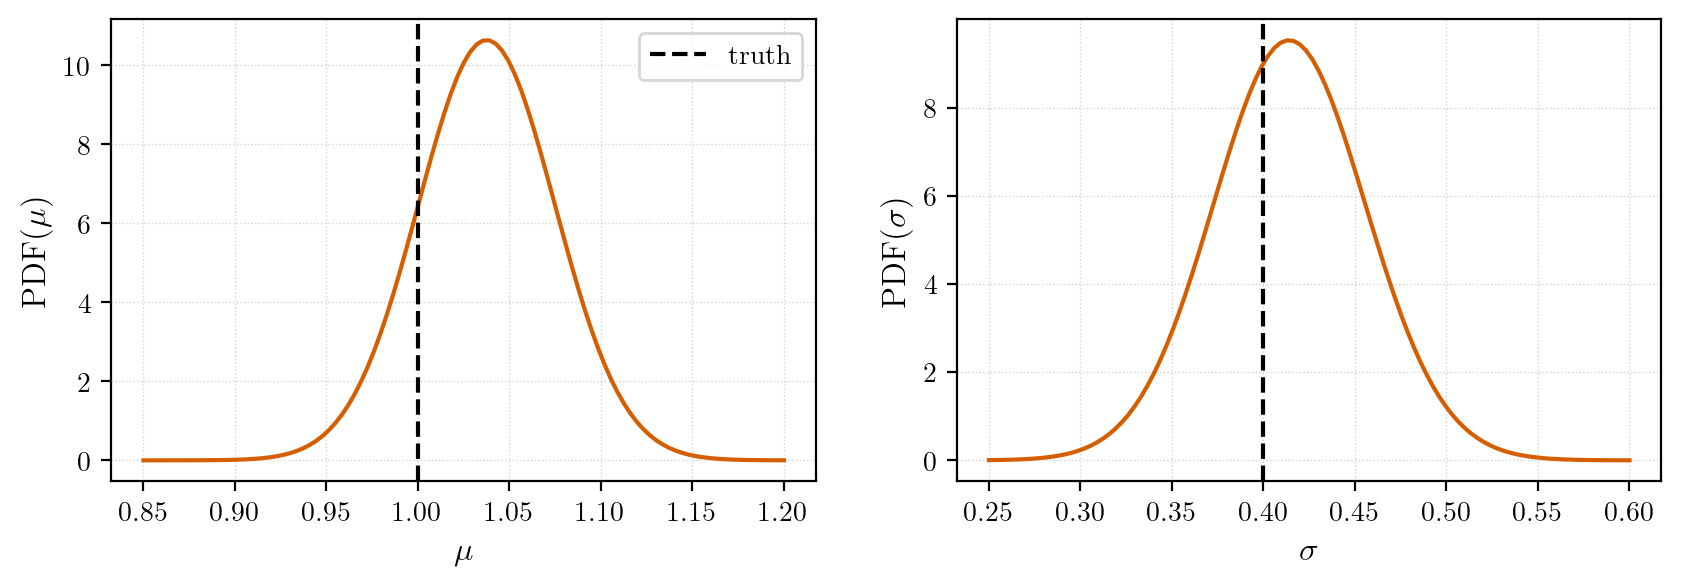

In [25]:
fig, axes = plt.subplots(1,2,figsize=(10,3))

axes[0].plot(mu_grid, p_mu, color='C3')
axes[0].set_xlabel('$\mu$')
axes[0].set_ylabel('PDF$(\mu)$')
axes[0].axvline(mu_pop_true, color='k',ls='--', label='truth')
axes[0].grid()
axes[0].legend()

axes[1].plot(sigma_grid, p_sigma, color='C3')
axes[1].set_xlabel('$\sigma$')
axes[1].set_ylabel('PDF$(\sigma)$')
axes[1].axvline(sigma_pop_true, color='k',ls='--')
axes[1].grid()

plt.show()

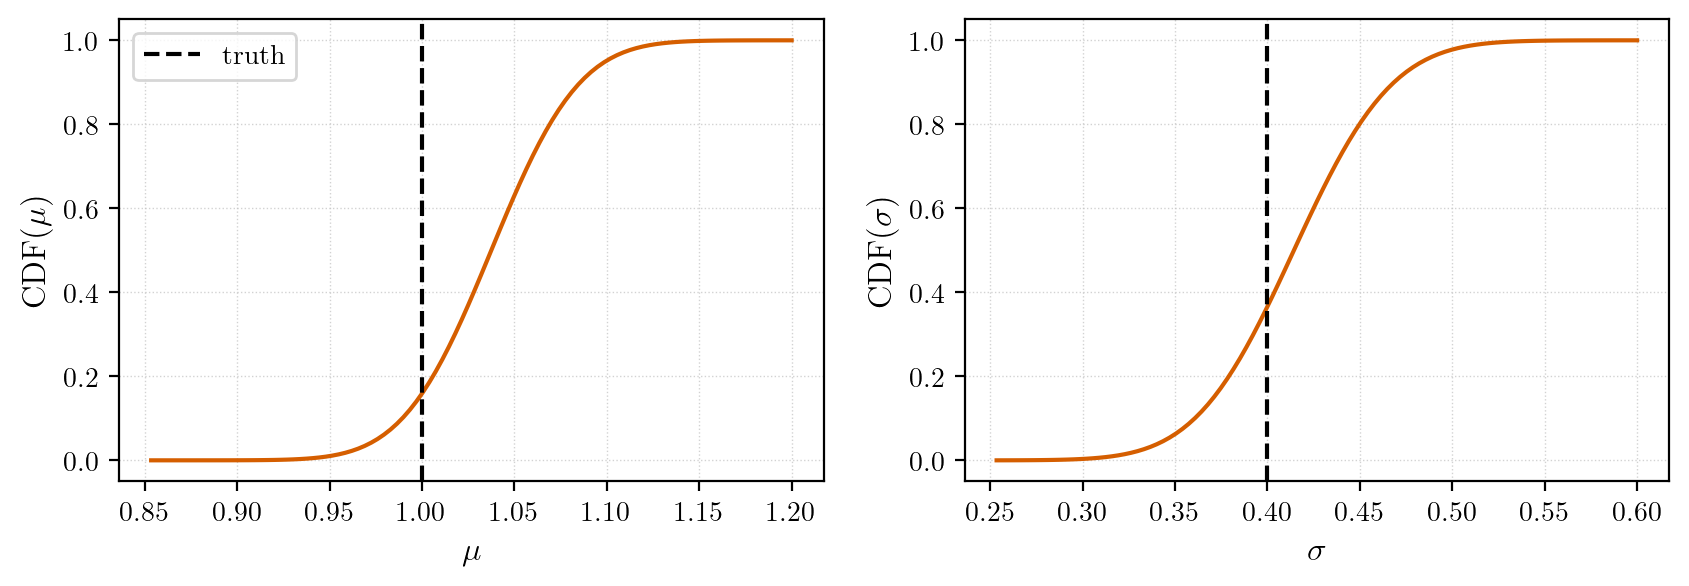

In [27]:
fig, axes = plt.subplots(1,2,figsize=(10,3))

axes[0].plot(mu_grid[1:], cdf_mu, color='C3')
axes[0].set_xlabel('$\mu$')
axes[0].set_ylabel('CDF$(\mu)$')
axes[0].axvline(mu_pop_true, color='k',ls='--', label='truth')
axes[0].grid()
axes[0].legend()

axes[1].plot(sigma_grid[1:], cdf_sigma, color='C3')
axes[1].set_xlabel('$\sigma$')
axes[1].set_ylabel('CDF$(\sigma)$')
axes[1].axvline(sigma_pop_true, color='k',ls='--')
axes[1].grid()

plt.show()

## Step 3: Posterior predictive distribution (PPD)

First, some more math: to get the PPD, we want to average our Gaussian distribution $p(x|\Lambda)$ over the hyper-posterior on $\Lambda$ given our observed data $\{d_i\}$:

$$ \mathrm{PPD}(x|\{d_i\}) = \int p(x|\Lambda) \, p(\Lambda|\{d_i\}) \, d\Lambda~,$$

Or equivalently, with $\Lambda = (\mu,\sigma)$: 

$$ \mathrm{PPD}(x|\{d_i\}) = \int_{0}^{\infty} \int_{-\infty}^{\infty} p(x|\mu, \sigma) \, p(\mu, \sigma|\{d_i\}) \, d\mu \,d\sigma$$

Using work from the top of the notebook: 

$$ \mathrm{PPD}(x|\{d_i\}) =\int_{0}^{\infty} \int_{-\infty}^{\infty}[2\pi \, \sigma^2]^{-1/2}  \mathrm{Exp}\Big[ -\frac{1}{2\sigma^2} (x-\mu)^2 \Big] ~ [2\pi \, (\sigma^2 + \sigma_{\rm meas}^2)]^{-N/2} \, \mathrm{Exp}\Bigg[ -\frac{1}{2 (\sigma^2 + \sigma_{\rm meas}^2)} \sum_{i}^N (x_{\mathrm{max}\mathcal{L},i} -\mu)^2\Bigg] \, d\mu \,d\sigma~.$$

And finally, simplifying a bit, we get: 
$$ \mathrm{PPD}(x|\{d_i\}) = (2\pi)^{-\frac{N+1}{2}} \int_{0}^{\infty} \int_{-\infty}^{\infty} \frac{1}{\sigma \,(\sigma^2+\sigma_{\rm meas}^2)^{N/2}}\mathrm{Exp}\Bigg[ -\frac{1}{2} \Bigg( \Big(\frac{x-\mu}{\sigma}^2 \Big) + \frac{\sum_{i}^N (x_{\mathrm{max}\mathcal{L},i} -\mu)}{\sigma^2 + \sigma_{\rm meas}^2} \Bigg)\Bigg] \, d\mu \,d\sigma~.$$

We can calculate this analytically.

In [28]:
# Broadcast arrays for easy computation
X  = x_grid[:, None, None]
MU = MU[None, :, :]
SIG = SIG[None, :, :]

# First, calculate the population distribution 
pop_dist = gaussian_pdf(X, MU, SIG)

# Second, multiply by the pre-computed hierarchical likelihood
integrand = pop_dist * hL[None, :, :]

# Third, integrate over mu and sigma
PPD = np.trapz(np.trapz(integrand, x=sigma_grid), x=mu_grid)

We can also calculate this numerically using draws from our hyperposterior. Let's see how well they agree.

In [44]:
# Draw from the hyperposterior using the CDFs on mu, sigma
mu_draws = np.interp(rng.uniform(size=10000), cdf_mu, mu_grid[1:])
sigma_draws = np.interp(rng.uniform(size=10000), cdf_sigma, sigma_grid[1:])

# Numerically calculate the PPD
p_x = np.empty((len(x_grid), len(mu_draws)))

for i, (mu, sig) in enumerate(zip(mu_draws, sigma_draws)): 
    p_x[:,i] = gaussian_pdf(x_grid, mu, sig)
    
PPD_numerical = np.average(p_x,axis=-1)

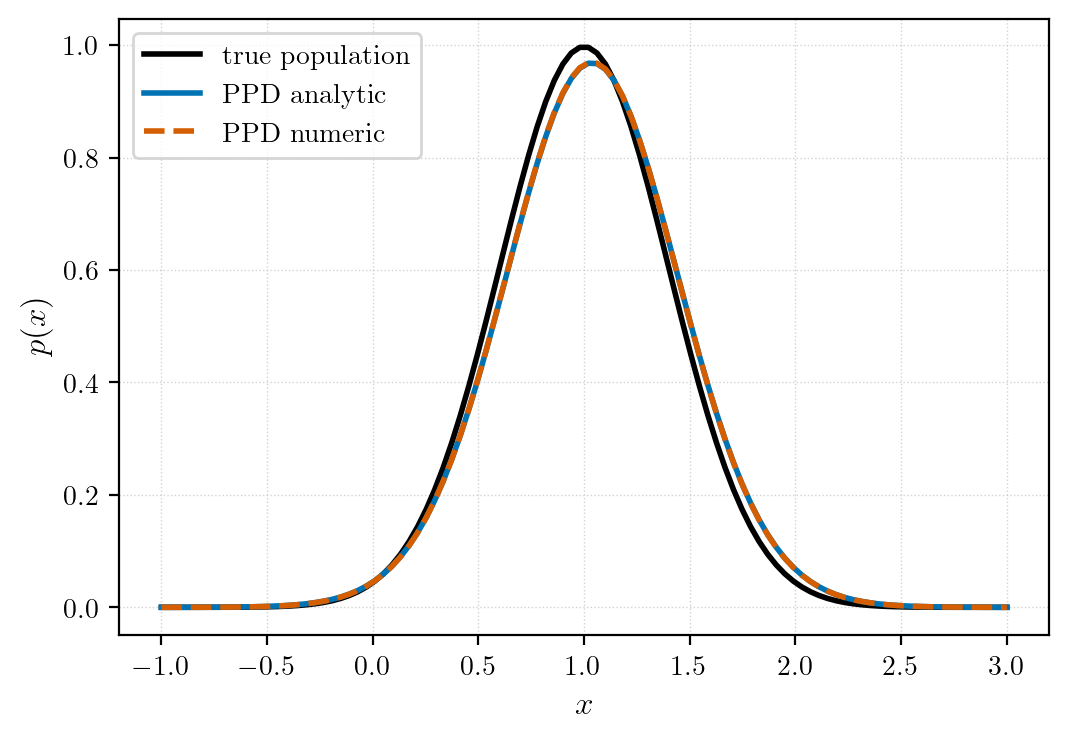

In [45]:
# Plot
plt.figure(figsize=(6,4))

plt.plot(x_grid, y_grid, color='k', lw=2, label='true population')
plt.plot(x_grid, PPD, lw=2, color='C0', label='PPD analytic')
plt.plot(x_grid, PPD_numerical, color='C3', ls='--', lw=2, label='PPD numeric')

plt.legend(loc='upper left')
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$')
plt.grid()

plt.show()

The numeric and analytic approaches agree nearly exactly! The benefit of the numeric approach is that then we can also easily get uncertainty estimates.

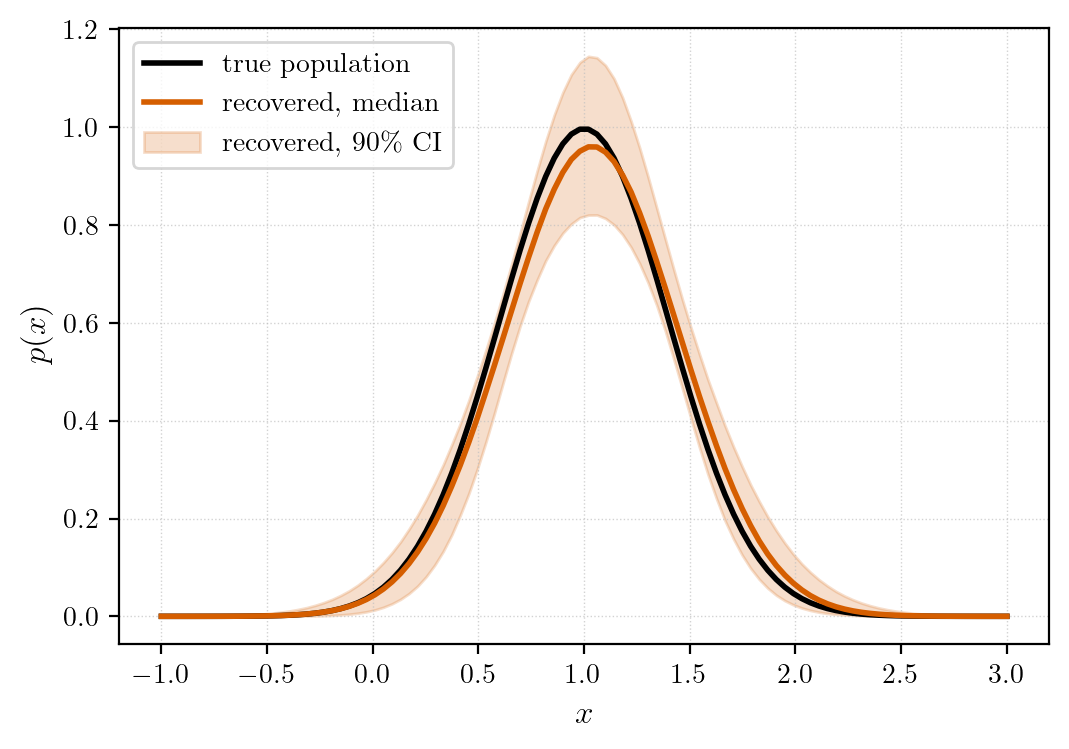

In [46]:
lower, med, upper = np.quantile(p_x, (0.05, 0.5, 0.95), axis=-1)

plt.figure(figsize=(6,4))
plt.plot(x_grid, y_grid, color='k', lw=2, label='true population')
plt.plot(x_grid, med, color='C3', lw=2, label='recovered, median')
plt.fill_between(x_grid, lower, y2=upper, color='C3', alpha=0.2, label='recovered, 90\% CI')
plt.legend(loc='upper left')
plt.xlabel(r'$x$')
plt.ylabel(r'$p(x)$')
plt.grid()
plt.show()

The truth lies within our 90% credible region, as expected.

## Step 4: Posterior predictive checks

### 4.1: Event level PPCs

Let's generate PPC traces corresponding to the $\mu, \sigma$ hyper-posterior draws above.

Here, "predicted" values are just draws from the population distribution: a Gaussian centered at $\mu$ with width $\sigma$ (there are no selection effects at play in this toy example).

For the "observed" values,  we must reweight our single-event posteriors to the Gaussian population model. This is achieved with the product of two Gaussian distributions. 

In [47]:
def gaussian_product(x, mu1, sigma1, mu2, sigma2):
    """
    Product of two Gaussian distributions described by (mu1, sigma1)
    and (mu2, sigma2)
    """
    coefficient = 1 / (2 * np.pi * sigma1 * sigma2)
    exponent = ((x - mu1) / sigma1)**2 + ((x - mu2) / sigma2)**2
    pdf_value = coefficient * np.exp(-0.5*exponent) 
    return pdf_value

In [59]:
PPC_traces_event = []
for mu, sigma in tqdm.tqdm(zip(mu_draws, sigma_draws)): 

    # "Predicted" are just a draws from the pop dist
    y_rep = np.random.normal(loc=mu, scale=sigma, size=nevents)

    # "Observed" are one draw per reweighted individual-event posterior
    y = np.zeros(len(y_rep))
    for i,xi in enumerate(x_maxL): 

        # reweighted individual-event posterior on a grid
        p_rw = gaussian_product(x_grid,xi,sigma_meas,mu,sigma)     

        # calculate CDF   
        cdf = np.cumsum(p_rw)
        cdf = cdf / cdf[-1]

        # draw from CDF and interpolate
        y[i] = np.interp(np.random.rand(), cdf, x_grid)
    
    PPC_traces_event.append(dict(y=y, y_rep=y_rep))

10000it [01:01, 163.21it/s]


## 4.2: Data-level PPCs (max. $\mathcal{L}$)

Here, we already have the observed values (these are stored in `x_maxL`). To calculate the predicted values, we draw true values and from those calculate maxmimum likelihood values under the Gaussian single-eventlikelihood.

In [49]:
PPC_traces_maxL = []
for mu, sigma in tqdm.tqdm(zip(mu_draws, sigma_draws)): 

    # Draw a true parameter from the underlying population distribution
    y_rep_true = rng.normal(loc=mu, scale=sigma, size=nevents)

    # From this, draw a maxL parameter
    y_rep = rng.normal(loc=y_rep_true, scale=sigma_meas)
    
    PPC_traces_maxL.append(dict(y=x_maxL, y_rep=y_rep))

10000it [00:00, 40011.60it/s]


### Compare

Plot the PPC traces and compare.

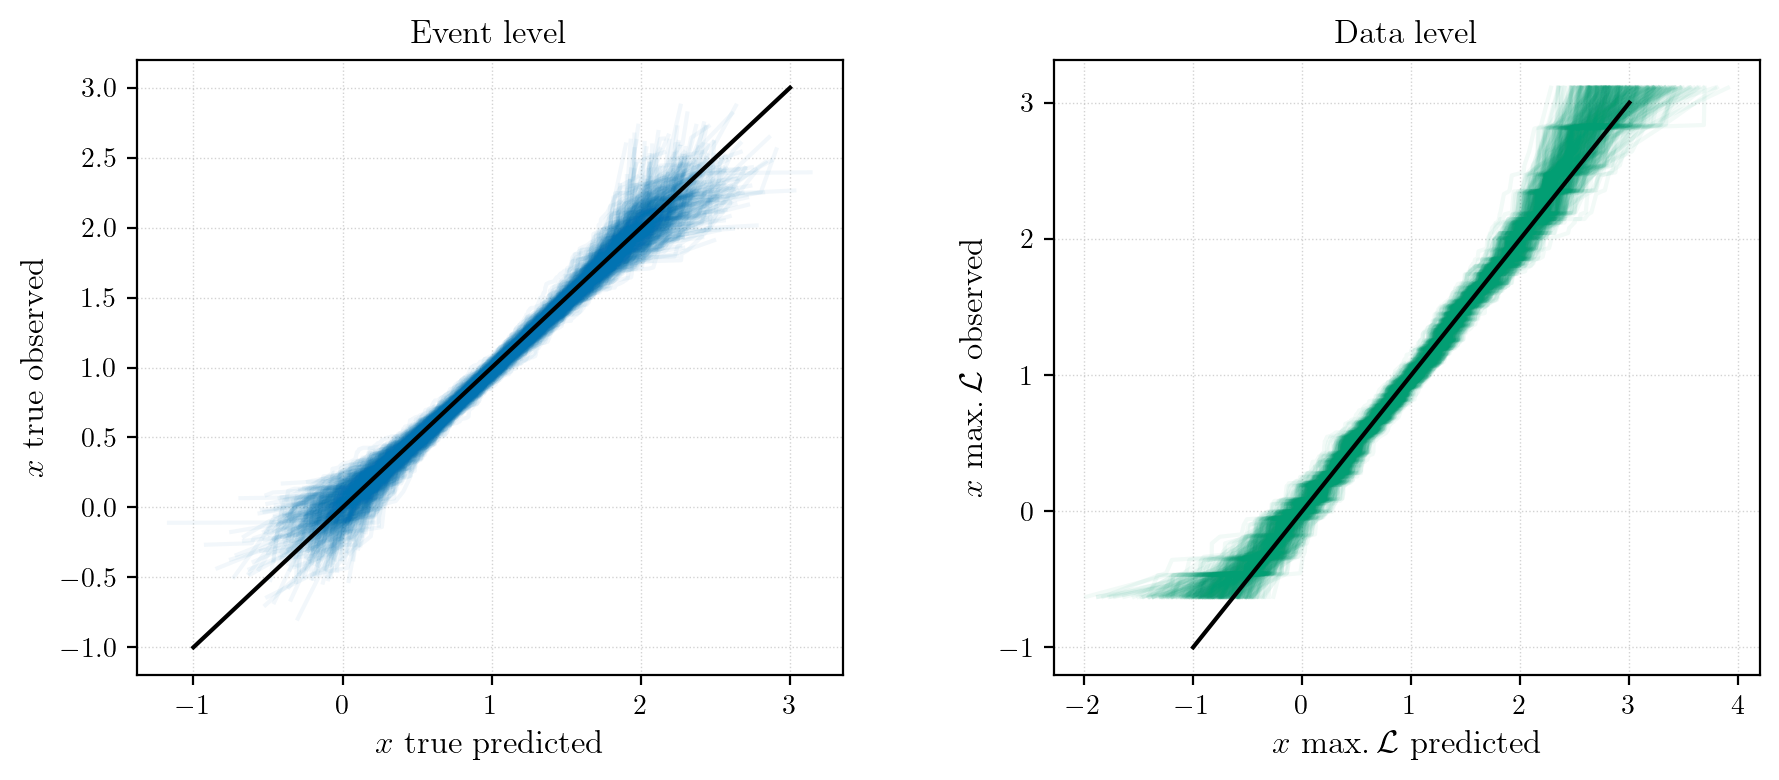

In [61]:
fig, axes = plt.subplots(1,2,figsize=(9,4))
diag = [-1,3]

nPlot = 500 # plot a smaller number of traces for better visibility

# Event level
for p in PPC_traces_event[:nPlot]: # plot 100 traces for better visibility
    axes[0].plot(np.sort(p['y_rep']), np.sort(p['y']), color='C0', alpha=0.05)
axes[0].set_xlabel('$x$ true predicted')
axes[0].set_ylabel('$x$ true  observed')
axes[0].set_title('Event level')

# Data level
for p in PPC_traces_maxL[:nPlot]:
    axes[1].plot(np.sort(p['y_rep']), np.sort(p['y']), color='C2', alpha=0.05)
axes[1].set_xlabel('$x$ $\mathrm{max}.\,\mathcal{L}$ predicted')
axes[1].set_ylabel('$x$ $\mathrm{max}.\,\mathcal{L}$  observed')
axes[1].set_title('Data level')

for ax in axes: 
    ax.plot(diag,diag, color='k')
    ax.grid()

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()